# 01 — Data preparation

**Goal.** Understand what is actually in these files before any modelling touches them.

| | |
|---|---|
| **Reads** | `data/raw/lalonde/*.txt` |
| **Writes** | `outputs/data/01_sample_cps.csv`, `01_sample_psid.csv`, `01_benchmark.json` |

**Questions this notebook answers**

1. What columns are there, and what does each one mean?
2. Are the data types right?
3. How are the numeric variables distributed?
4. Are there rows that need handling before modelling?
5. Are the categorical variables coded correctly?

Then, once the data is understood: what is the experimental benchmark, and what do the two
observational samples look like?

Every claim below is backed by output in the cell beside it. Nothing is asserted on trust.

In [1]:
import sys
sys.path.insert(0, "..")

# Reload src/ modules automatically whenever they change on disk. Without this,
# Python caches the module on first import and later edits to src/*.py are
# invisible until you restart the kernel.
%load_ext autoreload
%autoreload 2

import json
import warnings

# this environment ships slightly old numexpr/bottleneck; the warnings are noise
warnings.filterwarnings("ignore", message=".*numexpr.*")
warnings.filterwarnings("ignore", message=".*bottleneck.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src import psm, data, figures

pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

%matplotlib inline

## 1. What is in the files

Four files, ten columns each, no header row, whitespace separated.

**Who these people are.** The National Supported Work Demonstration ran from 1975 to 1979 and
targeted the hardest-to-employ: long-term welfare recipients, ex-offenders, recovering addicts,
and teenagers who had left school and never held steady work. Its premise was that the binding
constraint was not skills but the absence of any bridge into the labor market — no work history,
no references, and no employer willing to tolerate a slow start. So it offered 9 to 18 months of
paid work with close supervision and demands that ramped up gradually, across ten cities. More
applicants than places meant admission was decided by lottery, and that single administrative
choice is the only reason a ground truth exists here.

**Where each file comes from.** `nswre74_treated` and `nswre74_control` are the two arms of that
lottery. The other two are comparison groups LaLonde assembled from national surveys, and they
are not raw survey extracts:

- **CPS-1** comes from Westat's Matched Current Population Survey–Social Security Administration
  File, which links survey records to Social Security earnings records. That matching is why three
  separate years of earnings can sit on one row at all: a single CPS interview asks only about the
  previous year's income, so no one interview could produce 1974, 1975 and 1978 together.
- **PSID-1** comes from the Panel Study of Income Dynamics, which has followed the same families
  since 1968 and collects income by survey question.

That difference in collection method turns out to explain a lot of what sections 3 and 4 find.
See [docs/background.md](../docs/background.md) for the full story.

In [2]:
raw = data.load_lalonde()

for name, df in raw.items():
    print(f"{name:12s} {len(df):>6,} rows x {df.shape[1]} cols")

print(f"\nall four share identical columns: {all(list(df.columns) == data.COLUMNS for df in raw.values())}")
print(f"columns: {data.COLUMNS}")
print()
raw["nsw_treated"].head(3)

nsw_treated     185 rows x 10 cols
nsw_control     260 rows x 10 cols
cps          15,992 rows x 10 cols
psid          2,490 rows x 10 cols

all four share identical columns: True
columns: ['treat', 'age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75', 're78']



,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,1,37.00,11.00,1,0,1,1,0.00,0.00,"9,930.05"
1,1,22.00,9.00,0,1,0,1,0.00,0.00,"3,595.89"
2,1,30.00,12.00,1,0,0,0,0.00,0.00,"24,909.45"


## 2. Column meanings and data types

| Column | Meaning | Kind | Timing |
|---|---|---|---|
| `treat` | enrolled in the program | indicator | assignment |
| `age` | age in years | numeric | pre-treatment |
| `educ` | years of schooling completed | numeric | pre-treatment |
| `black` | is Black | indicator | pre-treatment |
| `hisp` | is Hispanic | indicator | pre-treatment |
| `married` | is married | indicator | pre-treatment |
| `nodegree` | no high school diploma | indicator | pre-treatment |
| `re74` | real earnings, 1974 | numeric, dollars | **pre-treatment** |
| `re75` | real earnings, 1975 | numeric, dollars | **pre-treatment** |
| `re78` | real earnings, 1978 | numeric, dollars | **outcome** |

`re78` is the outcome and must never enter a balance check or a propensity model. `re74` and
`re75` are covariates. The randomized arms let us verify that claim rather than assume it, which
we do in section 6.

**Why the indicators become `int8` and not `category`.** They take part in arithmetic
everywhere: `df.treat.mean()` is the treated share, `y[t == 1]` subsets an arm, and
scikit-learn's `fit(X, y)` wants a numeric label. A categorical dtype breaks all three. The rule:
a binary indicator used in modelling is `int8` or `bool`; `category` is for unordered variables
with three or more levels that need encoding first. Every categorical here is already binary, so
nothing in this project needs `category`.

In [3]:
# what the raw text files give us, before any conversion
rawest = pd.read_csv(data.RAW_DIR / "nswre74_treated.txt", sep=r"\s+",
                     header=None, names=data.COLUMNS)
print("as parsed from disk:")
print(rawest.dtypes.value_counts().to_string())

print(f"\nafter load_raw narrows the {len(data.INDICATORS)} indicators:")
print(raw["nsw_treated"].dtypes.to_string())

print(f"\narithmetic still works on the narrowed columns:")
print(f"  treated share of the CPS sample = {pd.concat([raw['nsw_treated'], raw['cps']]).treat.mean():.4f}")

as parsed from disk:
float64    10

after load_raw narrows the 5 indicators:
treat          int8
age         float64
educ        float64
black          int8
hisp           int8
married        int8
nodegree       int8
re74        float64
re75        float64
re78        float64

arithmetic still works on the narrowed columns:
  treated share of the CPS sample = 0.0114


## 3. Data quality, checked one file at a time

**Check per file first. Pool only once the per-file answers agree.**

Quality problems belong to a file, not to a dataset. Pooling averages them away, and it does so
here in a way that would have hidden the most important finding in this notebook: the pooled
maximum for 1978 earnings is $121,174, which looks perfectly healthy, because it comes from PSID.
CPS stops dead at $25,565.

`compare_files` runs the checks separately on each source and puts them side by side, so one
glance says where to look. The censoring test is automatic: a genuine continuous measurement has
an essentially unique maximum, so when a noticeable share of rows sit on exactly the largest
value, the variable was capped before release rather than measured that way.

In [4]:
report = data.compare_files()

print("STRUCTURAL CHECKS")
print(report[["n_rows", "n_missing", "n_negative_earnings",
              "n_duplicated", "pct_duplicated", "n_educ_zero"]].to_string())

print("\n\nCENSORING TEST on the three earnings columns")
print(report[[c for c in report.columns if c.startswith("re7")]].to_string())

STRUCTURAL CHECKS
            n_rows n_missing n_negative_earnings n_duplicated pct_duplicated n_educ_zero
nsw_treated    185         0                   0            4           2.16           0
nsw_control    260         0                   0           11           4.23           0
cps          15992         0                   0         1716          10.73          36
psid          2490         0                   0          154           6.18           3


CENSORING TEST on the three earnings columns
              re74_max re74_pct_at_max re74_censored   re75_max re75_pct_at_max re75_censored   re78_max re78_pct_at_max re78_censored
nsw_treated  35,040.07            0.54         False  25,142.24            0.54         False  60,307.93            0.54         False
nsw_control  39,570.68            0.38         False  23,031.98            0.38         False  39,483.53            0.38         False
cps          25,862.32           19.08          True  25,243.55           18.80      

Three things to follow up, and one relief.

The relief: **no missing values and no negative earnings anywhere.** Those are the checks that
would have forced imputation decisions, and they come back clean in all four files.

The follow-ups:

1. **CPS earnings are censored, and only CPS.** All three years flagged, with a fifth to a quarter
   of rows sitting on the cap. PSID and both NSW arms are untouched.
2. **Duplicated rows everywhere**, but five times more common in CPS (10.7%) than in the treated
   arm (2.2%).
3. **39 rows report zero years of schooling**, all in CPS and PSID, none in NSW.

These are not independent. The first turns out to cause the second.

### 3a. CPS earnings are capped

One in four CPS rows carries exactly $25,564.67 for `re78`, which is also the CPS maximum. A hard
ceiling with mass piled on it is censoring, not a rounding artefact.

**The likely cause is the Social Security taxable maximum.** CPS-1 takes its earnings from Social
Security records, and those records captured income only up to the amount that was actually taxed.
Anything above the ceiling was never written down. PSID shows no ceiling at all, which fits: PSID
asks respondents what they earned rather than reading it off a payroll filing.

**Why it matters downstream.** `re74` and `re75` are covariates in the propensity model. For
roughly a fifth of CPS candidates we cannot tell someone earning \$26k from someone earning
\$200k, so matching on those variables is really matching on "earnings up to the cap". It also
compresses CPS earnings variance artificially, worth remembering whenever a standard deviation of
CPS earnings is used as a denominator.

This cannot be repaired. Censored data cannot be uncensored. It is recorded as a limitation.

In [5]:
CAP = {c: raw["cps"][c].max() for c in ["re74", "re75", "re78"]}
print("the CPS cap values, and how much mass sits on them\n")
for c, v in CAP.items():
    n = int((raw["cps"][c] == v).sum())
    print(f"  {c}: ${v:>10,.2f}   {n:>5,} of {len(raw['cps']):,} rows  ({n/len(raw['cps']):>5.1%})")

print("\nsecond-highest distinct value, for comparison (a real max would be isolated):")
for c, v in CAP.items():
    below = raw["cps"].loc[raw["cps"][c] < v, c].max()
    print(f"  {c}: ${below:>10,.2f}   i.e. the cap sits ${v - below:,.2f} above it")

the CPS cap values, and how much mass sits on them

  re74: $ 25,862.32   3,052 of 15,992 rows  (19.1%)
  re75: $ 25,243.55   3,007 of 15,992 rows  (18.8%)
  re78: $ 25,564.67   4,145 of 15,992 rows  (25.9%)

second-highest distinct value, for comparison (a real max would be isolated):
  re74: $ 25,860.36   i.e. the cap sits $1.96 above it
  re75: $ 25,241.76   i.e. the cap sits $1.79 above it
  re78: $ 25,561.71   i.e. the cap sits $2.96 above it


### 3b. Duplicated rows: what they are, and what we do about them

Roughly one CPS row in ten is an exact duplicate of another. Before deciding anything, here is
what the numbers actually say.

In [6]:
dup = data.duplicate_profile()
print("DUPLICATE COUNTS")
print(dup[["n_rows", "repeats_only", "rows_in_group",
           "distinct_profiles", "largest_group", "pct_all_years_zero"]].to_string())

DUPLICATE COUNTS
             n_rows  repeats_only  rows_in_group  distinct_profiles  largest_group  pct_all_years_zero
nsw_treated     185             4              7                  3              3              100.00
nsw_control     260            11             18                  7              4              100.00
cps           15992          1716           2156                440             35               22.10
psid           2490           154            291                137              5               19.90


**Reading the table.** There are two honest ways to count duplicates and they give different
numbers, so both columns are here.

Take a profile that appears three times. `duplicated()` flags two of them, the second and third,
because it asks "have I seen this before?". `duplicated(keep=False)` flags all three, because it
asks "does this row have a twin anywhere?". A group of three therefore contributes 2 to one column
and 3 to the other, and the gap between the columns is the number of distinct profiles involved.

Reading the CPS row that way:

- **2,156** rows have at least one identical twin somewhere in the file.
- Among them there are only **440** distinct profiles, because most repeat several times over. The
  most repeated one appears **35** times.
- Running `drop_duplicates()` would delete **1,716** rows, keeping one copy of each of the 440.
- **22.1%** of those 2,156 rows report zero earnings in all three years, 1974, 1975 and 1978.

The NSW rows read the same way but are much smaller: 7 rows in duplicate groups come from only 3
distinct profiles, and **100%** of them have zero earnings throughout.

#### Observation

Only ten columns survive in this dataset, and most of them cannot tell two people apart. Four are
binary indicators (Black, Hispanic, married, no diploma) and two are coarse whole-number counts
(age and education in years). Two people who are both Black, unmarried, without a diploma, aged 17
with ten years of schooling are identical on six of the ten columns by construction.

Earnings is the only column with enough resolution to separate them, and each file loses that
resolution its own way:

| File | Why earnings stops separating people |
|---|---|
| NSW treated and control | genuinely zero earnings, for most of the target population |
| CPS | censored at the Social Security ceiling |
| PSID | income reported in round figures rather than exact amounts |

The next cell shows the last of those. PSID records only 610 distinct positive values for 1974
earnings across 2,275 people; CPS records 7,332 across 14,079.

In [7]:
res = data.earnings_resolution()
res["re74_pct_distinct"] = res.re74_n_distinct / res.re74_n_positive * 100
print("RESOLUTION OF 1974 EARNINGS  (positive values only; zero is shared by construction)")
print(res[["re74_n_positive", "re74_n_distinct", "re74_pct_distinct"]].round(1).to_string())

cps = raw["cps"]
grp = cps[cps.duplicated(keep=False)].groupby(data.COLUMNS).size().sort_values(ascending=False)
print(f"\nthe most-repeated CPS record, {grp.iloc[0]} copies:")
print(pd.Series(dict(zip(data.COLUMNS, grp.index[0]))).to_string())
print("  -> all three earnings years sit exactly on the cap")

tr = raw["nsw_treated"]
gt = tr[tr.duplicated(keep=False)].groupby(data.COLUMNS).size().sort_values(ascending=False)
print(f"\nthe most-repeated NSW treated record, {gt.iloc[0]} copies:")
print(pd.Series(dict(zip(data.COLUMNS, gt.index[0]))).to_string())
print("  -> all three earnings years are zero")

RESOLUTION OF 1974 EARNINGS  (positive values only; zero is shared by construction)
             re74_n_positive  re74_n_distinct  re74_pct_distinct
nsw_treated               54               52              96.30
nsw_control               65               65             100.00
cps                    14079             7332              52.10
psid                    2275              610              26.80

the most-repeated CPS record, 35 copies:
treat           0.00
age            33.00
educ           12.00
black           0.00
hisp            0.00
married         1.00
nodegree        0.00
re74       25,862.32
re75       25,243.55
re78       25,564.67
  -> all three earnings years sit exactly on the cap

the most-repeated NSW treated record, 3 copies:
treat       1.00
age        17.00
educ       10.00
black       1.00
hisp        0.00
married     0.00
nodegree    1.00
re74        0.00
re75        0.00
re78        0.00
  -> all three earnings years are zero


Duplicates concentrate exactly where earnings loses its resolution rather than scattering across
the distribution. That is what separates collision from genuine replication: if the same person
had been recorded twice, there would be no reason for the pairs to cluster at the cap and at zero.

#### Assumption

**Duplicated rows are different individuals who share the same recorded characteristics, not
repeated records of the same person.**

This is an assumption and it cannot be verified. The files carry no identifier, and the source
documentation describes rows only as "observations", never as individuals. What supports it beyond
the concentration pattern is provenance: CPS-1 is a matched CPS-SSA file, and that matching is
done on the person.

#### Decision

**Keep every row. No de-duplication anywhere in this project.**

The two arms are different kinds of object, so they get separate reasoning.

**The treated units are not negotiable.** We are estimating the ATT, which is defined over the
people who actually took the program. Those 185 rows *are* the population the estimate is about.
Dropping any of them would not make the estimate noisier, it would change what we are estimating.
So they stay, whatever they look like.

**The control pool is a genuine judgment call.** It exists only to supply counterfactuals, so
there is a real argument that two identical donors are redundant and one could go. I decided
against it, for five reasons:

1. **The propensity model is fit on treated and control together.** Dropping 1,716 control rows
   changes the control covariate distribution, hence the fitted coefficients, hence every
   propensity score, including those of all 185 treated units. The treated share alone moves from
   1.14% to 1.28%. Nothing downstream is insulated from that.
2. **Without replacement, duplicates are matching capacity.** A profile appearing 35 times can
   serve 35 different treated units, each taking its own copy. Deduped to one, it serves one. The
   donor pool shrinks precisely where it is densest, which is where the good matches live.
3. **Frequency is information about the population.** Thirty-five identical rows say that profile
   is common among controls. Collapsing them asserts it is as rare as a profile seen once, which
   corrupts the estimate of P(treated | X) directly.
4. **Nothing was removed upstream.** The distributed file still contains 1,716 exact CPS
   duplicates, so no de-duplication was applied to the published data either.
5. **Comparability.** Every published estimate on CPS-1 uses all 15,992 rows. Dropping rows would
   make these results uncheckable against the experimental benchmark and against four decades of
   literature, which is the entire reason for using this dataset.



### 3c. `educ == 0`: a real value, not a missing code

39 rows report zero years of schooling, all in CPS and PSID. That could be genuine, or a
missing-value code that was never documented.

The neighbouring counts decide it. A missing code would produce a sharp spike, but 0 appears less
often than 2 and about as often as 1 to 3, which is what a thin left tail looks like. At 0.2% of
the data the decision is low stakes either way. Recorded and left alone.

In [8]:
print("rows with educ == 0, by source file:")
print(report["n_educ_zero"].to_string())

print("\ncounts at the low end of educ, pooled (is 0 a spike?):")
educ_low = pd.concat(raw.values()).educ.value_counts().sort_index().head(6)
print(educ_low.to_string())

rows with educ == 0, by source file:
nsw_treated     0
nsw_control     0
cps            36
psid            3

counts at the low end of educ, pooled (is 0 a spike?):
educ
0.00     39
1.00     14
2.00     46
3.00     90
4.00    121
5.00    144


## 4. Numeric distributions, one group at a time

**Nothing in this section is pooled.** The treated arm is 1.1% of the CPS sample, so a pooled
histogram is a picture of the survey pool with the 185 participants invisible inside its first
bar. How far apart those two groups sit, and whether matching can close the gap, is the entire
question this project asks — pooling is the one view that cannot answer it.

So everything below splits three ways: the NSW participants, the CPS pool, the PSID pool. Both
pools are shown against the *same* participants, so the two can also be compared with each other.
That comparison matters later: section 7 treats CPS and PSID as two independent replications at
different difficulty levels, and this is the first place to see whether that is true.

`re78` is held back for section 4a. It is the outcome, and it never belongs beside the covariates.

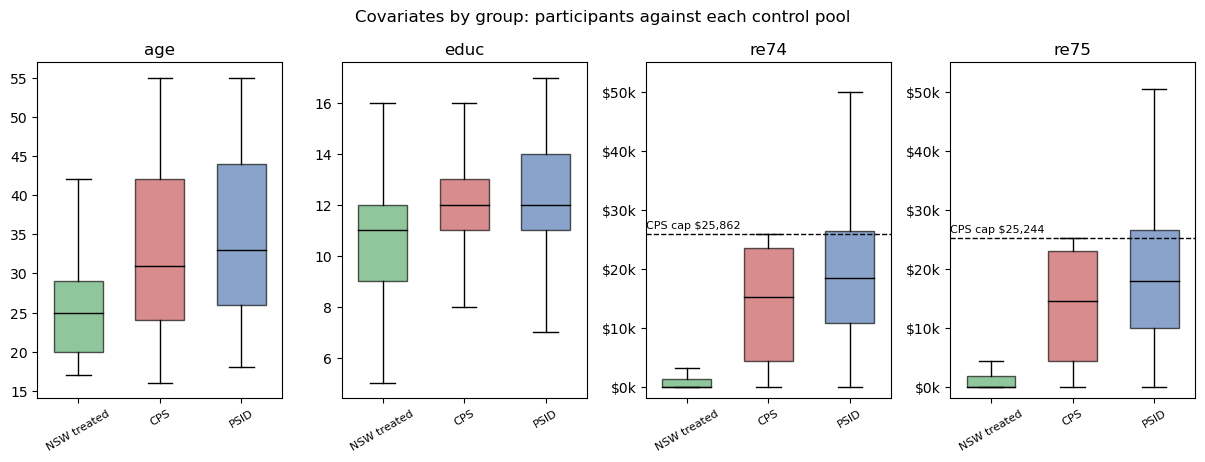

In [9]:
covs = ["age", "educ", "re74", "re75"]                      # re78 is the outcome, held back
groups = {"NSW treated": raw["nsw_treated"], "CPS": raw["cps"], "PSID": raw["psid"]}
COLOUR = {"NSW treated": "#55a868", "CPS": "#c44e52", "PSID": "#4c72b0"}

fig, axes = plt.subplots(1, 4, figsize=(figures.FIGSIZE[0] * 1.35, 4.4))
for ax, c in zip(axes, covs):
    bp = ax.boxplot([g[c].values for g in groups.values()], labels=list(groups),
                    widths=.6, patch_artist=True,
                    showfliers=False)          # 16k CPS rows would bury the panel in dots
    for patch, name in zip(bp["boxes"], groups):
        patch.set_facecolor(COLOUR[name])
        patch.set_alpha(.65)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(c)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)

for ax, c in zip(axes[2:], ["re74", "re75"]):
    ax.axhline(CAP[c], ls="--", lw=1, color="black")
    ax.annotate(f"CPS cap ${CAP[c]:,.0f}", xy=(0.5, CAP[c]), xytext=(0, 4),
                textcoords="offset points", fontsize=8)
    ax.set_ylim(-2_000, 55_000)                # PSID runs far past this; fliers are hidden anyway
    ax.set_yticks(range(0, 55_001, 10_000))
    ax.set_yticklabels([f"${v//1000}k" for v in range(0, 55_001, 10_000)])

fig.tight_layout()
fig.suptitle("Covariates by group: participants against each control pool", y=1.04)
figures.save_fig(fig, "covariate_boxplots", close=False)
plt.show()

In [10]:
# the one thing a boxplot cannot show: how much of each group is sitting exactly on zero
print("SHARE OF ROWS REPORTING NO EARNINGS AT ALL")
print(data.zero_share().to_string())

SHARE OF ROWS REPORTING NO EARNINGS AT ALL
             n_rows  re74_pct_zero  re75_pct_zero  re78_pct_zero
nsw_treated     185          70.80          60.00          24.30
nsw_control     260          75.00          68.50          35.40
cps           15992          12.00          10.90          13.60
psid           2490           8.60          10.00          11.50


**Reading the boxplots.**

1. **Age barely overlaps.** Three quarters of participants are younger than 29, which is below the
   median CPS respondent (31) and well below the median PSID respondent (33). Education overlaps
   much more: medians of 11 against 12, with the boxes sitting on top of each other.
2. **On prior earnings the groups are not on the same scale.** The participants' entire box —
   from the first quartile to the third — sits below \$1,300, while the CPS box spans \$4,400 to
   \$23,600 and the PSID box \$10,800 to \$26,500. Median 1974 earnings are \$0, \$15,124 and
   \$18,417 respectively. The participants' box looks collapsed because it is: the median is zero.
3. **The CPS cap is visible as a flat top.** The CPS whisker for `re74` and `re75` stops dead on
   the dashed line and goes no further, because that value is the maximum in the file. The PSID
   whisker beside it runs on past \$49,000. This is the censoring from 3a, seen rather than
   asserted — and it only appears once the files stop being pooled.
4. **PSID sits farther from the participants than CPS does** on both earnings columns. The two
   pools are not interchangeable, which is why section 7 keeps them strictly separate.

**Why so many zeros, and why it decides the whole project.**

71% of participants report no earnings at all in 1974, against 12% of CPS and 9% of PSID. That is
not a data-quality problem. It is a property of who was allowed to apply.

All four eligible groups were defined by long-term detachment from the labor market: women who had
been on AFDC for years, ex-addicts, ex-offenders, and 17-to-20 year-old school dropouts with a
delinquency record. Someone holding a steady job was not in the applicant pool to begin with.

Two consequences follow, and the second is the point of the project.

- **Prior earnings is not a low number, it is no number at all**, for most participants. A
  continuous variable cannot express the difference between "earned \$400" and "did not work", so
  a zero-earnings flag is the natural way to encode it. That is a modelling decision rather than a
  cleaning one, so notebook 02 adds the flag; this notebook records the fact that motivates it.
- **Selection into the program ran through pre-treatment earnings.** Being out of work is not a
  nuisance characteristic here, it is close to the eligibility rule itself. So `re74` and `re75`
  are not two covariates among ten — they carry most of the selection mechanism. That is exactly
  why dropping them flips the estimated effect from +\$1,752 to roughly -\$3,000 while the balance
  diagnostics on everything else still look fine. The headline finding of this repository is
  already visible in this histogram.

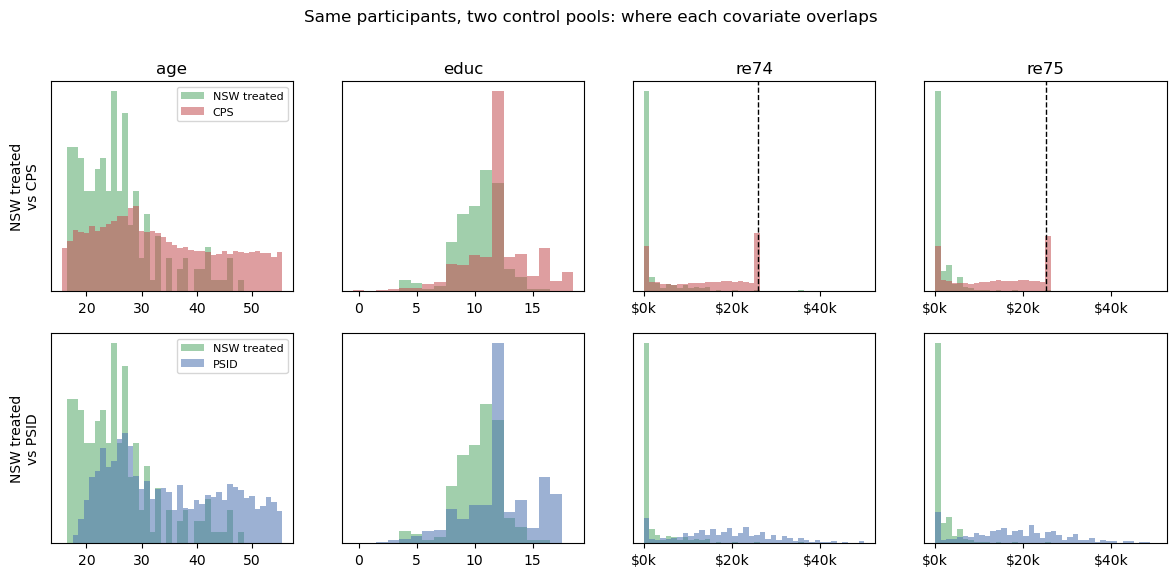

In [11]:
pools = [("CPS", raw["cps"]), ("PSID", raw["psid"])]
treated = raw["nsw_treated"]
CLIP = {"re74": (0, 50_000), "re75": (0, 50_000)}          # PSID has a thin tail beyond this

fig, axes = plt.subplots(2, 4, figsize=(figures.FIGSIZE[0] * 1.6, 6))
for j, c in enumerate(covs):
    if c in CLIP:                                           # fixed grid, shared by both rows
        bins = np.linspace(*CLIP[c], 41)
    else:                                                   # whole-number variables: one bin each
        lo = min(treated[c].min(), raw["cps"][c].min(), raw["psid"][c].min())
        hi = max(treated[c].max(), raw["cps"][c].max(), raw["psid"][c].max())
        bins = np.arange(lo - .5, hi + 1.5, 1)

    for i, (pool, df) in enumerate(pools):
        ax = axes[i, j]
        # density=True is not optional: the pools are 13x and 86x the size of the treated arm
        ax.hist(treated[c], bins=bins, density=True, alpha=.55,
                color=COLOUR["NSW treated"], label="NSW treated")
        ax.hist(df[c], bins=bins, density=True, alpha=.55, color=COLOUR[pool], label=pool)
        if pool == "CPS" and c in CLIP:
            ax.axvline(CAP[c], ls="--", lw=1, color="black")
        ax.set_yticks([])
        if c in CLIP:
            ax.set_xticks(range(0, 50_001, 20_000))
            ax.set_xticklabels([f"${v//1000}k" for v in range(0, 50_001, 20_000)])
        if i == 0:
            ax.set_title(c)
        if j == 0:
            ax.set_ylabel(f"NSW treated\nvs {pool}")
            ax.legend(fontsize=8)

fig.suptitle("Same participants, two control pools: where each covariate overlaps", y=1.0)
figures.save_fig(fig, "covariate_distributions", close=False)
plt.show()

**What the grid shows.** Both rows share the same bins and are plotted as densities, so the two
pools can be read against each other as well as against the participants.

- The spike at the left of both earnings panels *is* the participants. Neither survey pool has
  anything like it.
- The CPS earnings panels end in a bar sitting on the dashed cap line. The PSID panels beside them
  keep going, with a thin tail that continues past the \$50,000 clip.
- On `age` and `educ` the overlap is partial rather than absent. That is the honest read of what
  comes next: matching will have real candidates to draw on for demographics, and very few for
  anyone who worked before the program.

### 4a. The outcome, `re78`

`re78` gets its own figure, and it is the only place it appears in this notebook. It is `y`. It
must never enter a balance check or a propensity model, because
conditioning on the outcome would build the answer into the design.

It is shown here for one reason: the censoring found in 3a affects the outcome too, and a reader
should see how much of the CPS outcome distribution is stacked on a single value.

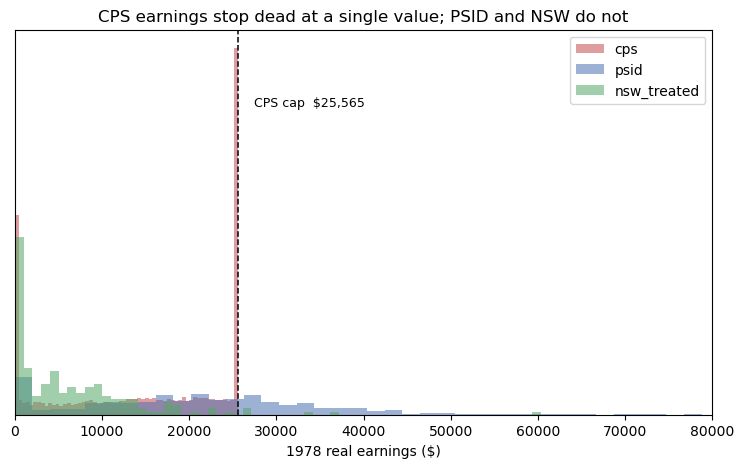

In [12]:
fig, ax = figures.new_fig()
for name, colour in [("cps", "#c44e52"), ("psid", "#4c72b0"), ("nsw_treated", "#55a868")]:
    ax.hist(raw[name].re78, bins=60, density=True, alpha=.55, label=name, color=colour)
ax.axvline(CAP["re78"], ls="--", lw=1.1, color="black")
ax.annotate(f"CPS cap  ${CAP['re78']:,.0f}", xy=(CAP["re78"], ax.get_ylim()[1] * .8),
            xytext=(12, 0), textcoords="offset points", fontsize=9)
ax.set_xlim(0, 80_000)
ax.set_xlabel("1978 real earnings ($)")
ax.set_yticks([])
ax.set_title("CPS earnings stop dead at a single value; PSID and NSW do not")
ax.legend()
figures.save_fig(fig, "earnings_topcode", close=False)
plt.show()

### Pooling, now that the distributions are done

Section 4 is the reason to be careful here. The *shape* of a variable differs by group, and that
difference is the subject of this project, so it must never be averaged away.

The remaining question is not like that. Whether an indicator contains only `0` and `1`, and
whether `black` and `hisp` are mutually exclusive, has the same answer in every file — these are
facts about the encoding, not about the people. Section 3 has already confirmed that no file
carries a structural problem the others do not. So section 5 works on all four stacked together,
with a `src` column preserving the origin for any breakdown that still needs one.

In [13]:
all_rows = pd.concat([df.assign(src=k) for k, df in raw.items()], ignore_index=True)
print(f"pooled frame: {len(all_rows):,} rows x {all_rows.shape[1]} cols "
      f"({' + '.join(str(len(d)) for d in raw.values())})")
all_rows.src.value_counts().to_frame("rows")

pooled frame: 18,927 rows x 11 cols (185 + 260 + 15992 + 2490)


,rows
src,
cps,15992
psid,2490
nsw_control,260
nsw_treated,185


## 5. The categorical columns, as given

Five columns are indicators: `treat`, `black`, `hisp`, `married`, `nodegree`. Three questions, and
they are the ones a cleaning stage owes the reader.

1. Are the values legal — only `0` and `1`, no stray codes?
2. Do they need encoding before a model can use them?
3. Is any of them unusable in practice, even though every value is legal?

The answer to the second is **no, nothing needs encoding**, and that is worth stating rather than
assuming: they arrive as numeric `0`/`1`, there are no strings, no `category` dtype and no missing
codes. The third question is the one that turns up something.

In [14]:
print("every indicator contains only 0 and 1:")
for c in data.INDICATORS:
    print(f"  {c:10s} unique values {sorted(all_rows[c].unique())}   dtype {all_rows[c].dtype}")

every indicator contains only 0 and 1:
  treat      unique values [0, 1]   dtype int8
  black      unique values [0, 1]   dtype int8
  hisp       unique values [0, 1]   dtype int8
  married    unique values [0, 1]   dtype int8
  nodegree   unique values [0, 1]   dtype int8


### Race: already k-1 dummy coded, with an implicit reference group

`black` and `hisp` never both equal 1, and the two of them plus "neither" account for exactly
100% of every file. That is the signature of a three-level categorical stored as k-1 = 2 dummies,
with the third level as the omitted reference.

**So there is nothing to do.** One-hot encoding these again, or adding a third "other" indicator,
would make the set perfectly collinear because the three would always sum to one. Coefficients on
`black` and `hisp` are already read relative to the reference group.

**What the reference group hides.** It pools everyone who is neither Black nor Hispanic, so white,
Asian, Native American and other respondents are indistinguishable — 85.4% of CPS falls into this
single bucket. Asian participants cannot be identified, and therefore cannot be matched on. If
that status relates to both program entry and later earnings, it is an unmeasured confounder. This
is a limitation of 1970s data collection, not something the analysis can fix, and it belongs in
the write-up.

In [15]:
print("black x hisp, pooled across all files")
print(pd.crosstab(all_rows.black, all_rows.hisp))
print(f"\n  rows with black == 1 and hisp == 1 : {int(((all_rows.black==1)&(all_rows.hisp==1)).sum())}")

race = pd.DataFrame({
    name: {"black %": df.black.mean()*100, "hisp %": df.hisp.mean()*100,
           "neither % (reference)": ((df.black==0)&(df.hisp==0)).mean()*100}
    for name, df in raw.items()
}).T
race["sums to"] = race.sum(axis=1)
print("\nthe three categories account for every row:")
race.round(1)

black x hisp, pooled across all files
hisp       0     1
black             
0      15484  1272
1       2171     0

  rows with black == 1 and hisp == 1 : 0

the three categories account for every row:


,black %,hisp %,neither % (reference),sums to
nsw_treated,84.30,5.90,9.70,100.00
nsw_control,82.70,10.80,6.50,100.00
cps,7.40,7.20,85.40,100.00
psid,25.10,3.30,71.70,100.00


### Legal values are not the same as usable columns

Every indicator passes the validity check. That only says the values are legal; it does not say
there are enough of them to model with. For that, counts are needed rather than percentages.

In [16]:
prev = pd.DataFrame({
    name: {"n_rows": len(df), **{c: int(df[c].sum()) for c in ["black", "hisp", "married", "nodegree"]}}
    for name, df in raw.items()
}).T
print("HOW MANY ROWS CARRY EACH INDICATOR (counts, not shares)")
print(prev.to_string())

print("\nthe same thing as shares, for comparison:")
print((prev[["black", "hisp", "married", "nodegree"]]
       .div(prev.n_rows, axis=0) * 100).round(1).to_string())

HOW MANY ROWS CARRY EACH INDICATOR (counts, not shares)
             n_rows  black  hisp  married  nodegree
nsw_treated     185    156    11       35       131
nsw_control     260    215    28       40       217
cps           15992   1176  1152    11382      4731
psid           2490    624    81     2157       760

the same thing as shares, for comparison:
             black  hisp  married  nodegree
nsw_treated  84.30  5.90    18.90     70.80
nsw_control  82.70 10.80    15.40     83.50
cps           7.40  7.20    71.20     29.60
psid         25.10  3.30    86.60     30.50


**`hisp` is eleven people.** Not 5.9% of the treated arm — eleven individuals, with 81 candidates
in the whole PSID pool to match them against. The share makes it look like an ordinary minority
category; the count shows it is a very thin cell. A rare indicator in a group of 185 is the kind
of column that pushes a logistic model towards separation and leaves almost nothing to match on,
so notebook 02 has to decide what to do about it. This is exactly what a percentage hides.

**`black` and `married` run in opposite directions between the arms.** 156 of 185 participants are
Black (84%) against 7% of CPS respondents. 19% of participants are married against 71% of CPS and
87% of PSID. Nothing here is invalid — these are simply the categorical columns carrying the
imbalance, the same story section 4 told for the numeric ones.

**Nothing is dropped or recoded on the strength of this.** It is the inventory the modelling
notebook needs, not an intervention.

### `nodegree` is computed from `educ`, not measured

`educ` is years of schooling. `nodegree` is whether the person has a high school diploma: 1 means
no diploma. US high school finishes at twelve years, so "no diploma" ought to mean "fewer than
twelve years of schooling" — and in this data it means exactly that, with no exceptions at all.
Both off-diagonal cells of the crosstab below are zero across all 18,927 rows.

So given `educ` you can work out `nodegree` with certainty. The two columns hold one fact twice,
the way a table holding both birth year and age does.

**That perfect agreement is itself the finding.** In reality the two should *not* line up exactly.
People complete twelve years and still leave without a diploma; other people earn a GED with
fewer. A relationship this clean means `nodegree` was never collected separately — someone
computed it from `educ` with the rule `educ < 12`. It is a recoding, not independent evidence
about the person.

**Neither column gets dropped, and there is nothing to fix here.** Worth being precise about why,
because "redundant" is too strong. The two are deterministically related but *not* collinear: a
logistic regression is linear in the log-odds, so from `educ` alone it can only tilt, and it cannot
produce the cliff at twelve years. `nodegree` is what supplies that cliff. The correlation is
-0.73, not -1. Which of the two a model should use, and whether it needs both, is a question about
functional form that belongs in notebook 02, where it can be settled by looking at balance.

In [17]:
print("educ < 12  vs  nodegree == 1")
print(pd.crosstab(all_rows.educ < 12, all_rows.nodegree,
                  rownames=["educ < 12"], colnames=["nodegree"]))
mismatch = int(((all_rows.educ < 12) != (all_rows.nodegree == 1)).sum())
print(f"\n  rows where the two disagree: {mismatch} out of {len(all_rows):,}")

# deterministic, but not collinear: a straight line through educ cannot make the step at 12
print(f"\n  corr(educ, nodegree)          : {all_rows.educ.corr(all_rows.nodegree):.2f}")
X = np.c_[np.ones(len(all_rows)), all_rows.educ.values]
b = np.linalg.lstsq(X, all_rows.nodegree.values, rcond=None)[0]
resid = all_rows.nodegree.values - X @ b
r2 = 1 - (resid ** 2).sum() / ((all_rows.nodegree - all_rows.nodegree.mean()) ** 2).sum()
print(f"  best LINEAR fit of nodegree from educ alone: R^2 = {r2:.2f}")
print("  -> the other half is the cliff at 12 years, which educ alone cannot express")


educ < 12  vs  nodegree == 1
nodegree       0     1
educ < 12             
False      13088     0
True           0  5839

  rows where the two disagree: 0 out of 18,927

  corr(educ, nodegree)          : -0.73
  best LINEAR fit of nodegree from educ alone: R^2 = 0.54
  -> the other half is the cliff at 12 years, which educ alone cannot express


## 6. The experimental benchmark

Now that the data is understood, the answer key.

Admission was decided by lottery, so the two randomized arms are comparable on everything,
measured or not, and a plain difference in mean `re78` is already unbiased. No modelling required.

This also lets us **verify** the pre- versus post-treatment claim from section 2 instead of
assuming it. Under randomization, any variable measured before treatment must come out balanced.
Anything the treatment moved will not.

In [18]:
exp = data.build_experimental()

print("BALANCE TEST INSIDE THE RANDOMIZED EXPERIMENT")
print("(a genuinely pre-treatment variable must show no difference)\n")
rows = []
for v in ["re74", "re75", "re78"]:
    a, b = exp.loc[exp.treat == 1, v], exp.loc[exp.treat == 0, v]
    tt = stats.ttest_ind(a, b, equal_var=False)
    rows.append({"variable": v, "treated": a.mean(), "control": b.mean(),
                 "difference": a.mean() - b.mean(), "p_value": tt.pvalue})
print(pd.DataFrame(rows).set_index("variable").round(3).to_string())
print("\n  re74 and re75 are balanced -> pre-treatment, safe as covariates")
print("  re78 is not             -> this is the outcome")

BALANCE TEST INSIDE THE RANDOMIZED EXPERIMENT
(a genuinely pre-treatment variable must show no difference)

          treated  control  difference  p_value
variable                                       
re74     2,095.57 2,107.03      -11.45     0.98
re75     1,532.06 1,266.91      265.15     0.39
re78     6,349.14 4,554.80    1,794.34     0.01

  re74 and re75 are balanced -> pre-treatment, safe as covariates
  re78 is not             -> this is the outcome


In [19]:
y_t = exp.loc[exp.treat == 1, "re78"]
y_c = exp.loc[exp.treat == 0, "re78"]

bench_est = y_t.mean() - y_c.mean()
test = stats.ttest_ind(y_t, y_c, equal_var=False)      # Welch: unequal variances
ci_lo, ci_hi = test.confidence_interval(0.95)

print(f"treated mean 1978 earnings : ${y_t.mean():>9,.0f}  (n={len(y_t)})")
print(f"control mean 1978 earnings : ${y_c.mean():>9,.0f}  (n={len(y_c)})")
print(f"\nBENCHMARK ATT              : ${bench_est:>9,.0f}")
print(f"95% CI                     : [${ci_lo:,.0f}, ${ci_hi:,.0f}]   width ${ci_hi-ci_lo:,.0f}")
print(f"p-value                    : {test.pvalue:.4f}")

treated mean 1978 earnings : $    6,349  (n=185)
control mean 1978 earnings : $    4,555  (n=260)

BENCHMARK ATT              : $    1,794
95% CI                     : [$474, $3,115]   width $2,641
p-value                    : 0.0079


### What randomization bought

The two randomized arms are near-identical on their covariates: under a year apart in age, a
quarter of a year in education, a point in race. Nobody adjusted anything to produce that.

Hold this table in mind. In the next section the control group is replaced, and the same
comparison falls apart.

In [20]:
# the eight pre-treatment covariates as they come in the file
covs = ["age", "educ", "black", "hisp", "married", "nodegree", "re74", "re75"]
arms = exp.groupby("treat")[covs].mean().T
arms.columns = ["NSW control (n=260)", "NSW treated (n=185)"]
arms["difference"] = arms.iloc[:, 1] - arms.iloc[:, 0]
arms

,NSW control (n=260),NSW treated (n=185),difference
age,25.05,25.82,0.76
educ,10.09,10.35,0.26
black,0.83,0.84,0.02
hisp,0.11,0.06,-0.05
married,0.15,0.19,0.04
nodegree,0.83,0.71,-0.13
re74,"2,107.03","2,095.57",-11.45
re75,"1,266.91","1,532.06",265.15


## 7. Build the two observational samples

The research design of LaLonde (1986): discard the 260 randomized controls, pretend we only ever
had the 185 participants, and take a comparison group from a national survey instead.

Two survey pools are used and they are kept **strictly separate**. They are two independent
replications of the same test at different difficulty levels, and merging them would let the
matching step draw from whichever pool is easier, hiding the very problem worth exposing.

In [21]:
samples = {pool: data.build_observational(pool) for pool in ["cps", "psid"]}

rows = []
for pool, df in samples.items():
    t, c = df.loc[df.treat == 1, "re78"], df.loc[df.treat == 0, "re78"]
    rows.append({"pool": pool.upper(),
                 "n_treated": int((df.treat == 1).sum()),
                 "n_control": int((df.treat == 0).sum()),
                 "treated_share": (df.treat == 1).mean(),
                 "mean_re78_treated": t.mean(),
                 "mean_re78_control": c.mean(),
                 "naive_difference": t.mean() - c.mean()})
pd.DataFrame(rows).set_index("pool")

,n_treated,n_control,treated_share,mean_re78_treated,mean_re78_control,naive_difference
pool,,,,,,
CPS,185,15992,0.01,"6,349.14","14,846.66","-8,497.52"
PSID,185,2490,0.07,"6,349.14","21,553.92","-15,204.78"


The naive comparison is not merely biased. It has the **wrong sign** and is off by more than ten
thousand dollars. Read literally, it says job training destroyed participants' earnings.

It also shows the pools are not interchangeable: PSID respondents earn more, so the same treated
group looks even worse against them. And treated units are a small minority of each sample, about
1% under CPS and 7% under PSID, which is what will push the propensity scores in notebook 02
towards zero.

Measuring *how* far apart the groups are belongs with the propensity model, since that is the
imbalance the model exists to correct, so it moves to notebook 02 where the before-and-after
comparison can sit side by side.

## 8. Save

Each notebook hands its work to the next through files rather than memory, so any stage can be
re-run alone and a reader can inspect the intermediate products on GitHub without executing
anything. The benchmark goes out as JSON so notebook 04 can score its estimates without reloading
the experimental arms.

In [22]:
for pool, df in samples.items():
    path = data.save_stage(df, f"01_sample_{pool}")
    print(f"{path.name:24s} {df.shape[0]:>6,} rows x {df.shape[1]} cols")

bench = {
    "estimand": "ATT",
    "outcome": "re78",
    "estimate": float(bench_est),
    "ci_lo": float(ci_lo),
    "ci_hi": float(ci_hi),
    "p_value": float(test.pvalue),
    "n_treated": int(len(y_t)),
    "n_control": int(len(y_c)),
    "source": "NSW randomized experiment (Dehejia-Wahba re74 subsample)",
}
bench_path = data.OUT_DIR / "01_benchmark.json"
bench_path.write_text(json.dumps(bench, indent=2))
print(f"\n{bench_path.name}: ${bench['estimate']:,.0f}  [{bench['ci_lo']:,.0f}, {bench['ci_hi']:,.0f}]")

01_sample_cps.csv        16,177 rows x 10 cols
01_sample_psid.csv        2,675 rows x 10 cols

01_benchmark.json: $1,794  [474, 3,115]
